# CLIP Fine-Tuning — DeepFashion In-Shop Retrieval
- Model: ViT-L/14, full vision encoder, text encoder frozen
- Loss: NT-Xent multi-positive in-batch negatives
- DDP via torchrun across 2x T4

In [1]:
!pip install -q ftfy regex tqdm open_clip_torch matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 24.8 MB/s eta 0:00:00


In [2]:
import torch
for i in range(torch.cuda.device_count()):
    print(f"GPU{i}: {torch.cuda.get_device_name(i)}  {round(torch.cuda.get_device_properties(i).total_memory/1e9,1)} GB")
print("Total GPUs:", torch.cuda.device_count())

GPU0: Tesla T4  15.6 GB
GPU1: Tesla T4  15.6 GB
Total GPUs: 2


In [3]:
%%writefile /kaggle/working/train_clip.py
import os, json, random, math
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.distributed as dist
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data import Dataset, DataLoader, DistributedSampler
from torch.amp import autocast, GradScaler
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
import open_clip

# ══════════════════════════════════════════════════════════════════════════════
# CONFIG
# ══════════════════════════════════════════════════════════════════════════════
DATASET_ROOT   = Path("/kaggle/input/datasets/vinay1706/deepfashion-cropped")
CAPTIONS_CSV   = DATASET_ROOT / "blip2_captions_train.csv"
TRAIN_CSV      = DATASET_ROOT / "train.csv"
OUT_DIR        = Path("/kaggle/working")

CLIP_MODEL     = "ViT-L-14"
CLIP_PRETRAIN  = "openai"
FINETUNE_SCOPE = "full"   # "full" or "last4"

VAL_SPLIT      = 0.1
EPOCHS         = 10
BATCH_SIZE     = 64       # total across all GPUs
LR             = 1e-5
WEIGHT_DECAY   = 0.01
WARMUP_EPOCHS  = 1
TEMPERATURE    = 0.07
SEED           = 42
ALPHA          = 0.7
P_ITEMS        = 16   # items per batch (BalancedBatchSampler)
K_IMAGES       = 2    # images per item (BalancedBatchSampler)

# ══════════════════════════════════════════════════════════════════════════════
# DATASET
# ══════════════════════════════════════════════════════════════════════════════
class DeepFashionDataset(Dataset):
    def __init__(self, records, transform, dataset_root):
        self.records      = records
        self.transform    = transform
        self.dataset_root = Path(dataset_root)

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        image_name, item_id = self.records[idx]
        try:
            img = Image.open(self.dataset_root / image_name).convert("RGB")
            img = self.transform(img)
        except Exception:
            img = torch.zeros(3, 224, 224)
        return img, item_id


def build_datasets(preprocess_train, preprocess_val, rank):
    train_df    = pd.read_csv(TRAIN_CSV)
    captions_df = pd.read_csv(CAPTIONS_CSV)
    captioned   = set(captions_df["image_name"].tolist())
    train_df    = train_df[train_df["image_name"].isin(captioned)].reset_index(drop=True)

    all_items = train_df["item_id"].unique().tolist()
    random.seed(SEED)
    random.shuffle(all_items)
    n_val       = int(len(all_items) * VAL_SPLIT)
    val_items   = set(all_items[:n_val])
    train_items = set(all_items[n_val:])

    train_records = [(r.image_name, r.item_id) for r in train_df.itertuples() if r.item_id in train_items]
    val_records   = [(r.image_name, r.item_id) for r in train_df.itertuples() if r.item_id in val_items]

    if rank == 0:
        print("Total captioned train images:", len(train_df))
        print("Train:", len(train_records), "images |", len(train_items), "items")
        print("Val  :", len(val_records),   "images |", len(val_items),   "items")

    train_ds = DeepFashionDataset(train_records, preprocess_train, DATASET_ROOT)
    val_ds   = DeepFashionDataset(val_records,   preprocess_val,   DATASET_ROOT)
    return train_ds, val_ds



# ══════════════════════════════════════════════════════════════════════════════
# BALANCED BATCH SAMPLER  (P items × K images per batch)
# ══════════════════════════════════════════════════════════════════════════════
class BalancedBatchSampler:
    """Yields batches of exactly P*K indices, each batch containing K images
    from each of P randomly chosen items.  Guarantees every batch has positive
    pairs for NT-Xent loss.  Works with DistributedSampler logic manually."""

    def __init__(self, records, num_replicas, rank, p=16, k=2, seed=42, drop_last=True):
        self.rank         = rank
        self.num_replicas = num_replicas
        self.p            = p   # items per batch
        self.k            = k   # images per item
        self.seed         = seed
        self.epoch        = 0

        # Build item -> list[index] map
        from collections import defaultdict
        item_to_idx = defaultdict(list)
        for i, (_, item_id) in enumerate(records):
            item_to_idx[item_id].append(i)
        # Keep only items with >= k images
        self.item_to_idx = {iid: idxs for iid, idxs in item_to_idx.items() if len(idxs) >= k}
        self.item_ids    = list(self.item_to_idx.keys())

        # Estimate batches per epoch (total batches across all replicas)
        total_batches = len(self.item_ids) // p
        # Each replica gets an equal slice
        self.num_batches = total_batches // num_replicas

    def set_epoch(self, epoch):
        self.epoch = epoch

    def __len__(self):
        return self.num_batches

    def __iter__(self):
        rng = random.Random(self.seed + self.epoch)
        shuffled_items = self.item_ids[:]
        rng.shuffle(shuffled_items)

        # Build all batches for this epoch across all replicas
        all_batches = []
        for start in range(0, len(shuffled_items) - self.p + 1, self.p):
            chosen_items = shuffled_items[start:start + self.p]
            batch = []
            for iid in chosen_items:
                pool = self.item_to_idx[iid]
                batch.extend(rng.sample(pool, min(self.k, len(pool))))
            if len(batch) == self.p * self.k:
                all_batches.append(batch)

        # Assign this rank's slice
        rank_batches = all_batches[self.rank::self.num_replicas]
        for batch in rank_batches[:self.num_batches]:
            yield batch


# ══════════════════════════════════════════════════════════════════════════════
# LOSS
# ══════════════════════════════════════════════════════════════════════════════
class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, embeddings, item_ids):
        B      = embeddings.size(0)
        device = embeddings.device
        sim    = torch.matmul(embeddings, embeddings.T) / self.temperature

        ids      = np.array(item_ids)
        pos_mask = torch.tensor(
            (ids[:, None] == ids[None, :]) & ~np.eye(B, dtype=bool),
            dtype=torch.bool, device=device
        )
        has_pos = pos_mask.any(dim=1)
        if not has_pos.any():
            # FIX: graph-connected zero so scaler records inf-checks
            return (embeddings * 0).sum()

        sim_f      = sim[has_pos]
        pos_mask_f = pos_mask[has_pos]

        orig_idx = has_pos.nonzero(as_tuple=True)[0]
        # FIX: vectorised self-mask
        diag_mask = torch.zeros_like(sim_f, dtype=torch.bool)
        for i, oi in enumerate(orig_idx):
            diag_mask[i, oi] = True
        sim_f = sim_f.masked_fill(diag_mask, -1e4)  # -1e9 overflows fp16; -1e4 is safely large

        log_prob     = sim_f - torch.logsumexp(sim_f, dim=1, keepdim=True)
        pos_log_prob = (log_prob * pos_mask_f).sum(dim=1) / pos_mask_f.sum(dim=1).float()
        return -pos_log_prob.mean()


# ══════════════════════════════════════════════════════════════════════════════
# FREEZE STRATEGY
# ══════════════════════════════════════════════════════════════════════════════
def configure_clip(model, scope, rank):
    for p in model.parameters():
        p.requires_grad = False

    visual = model.visual
    if scope == "full":
        for p in visual.parameters():
            p.requires_grad = True
    elif scope == "last4":
        for block in visual.transformer.resblocks[-4:]:
            for p in block.parameters():
                p.requires_grad = True
        if hasattr(visual, "proj") and visual.proj is not None:
            visual.proj.requires_grad = True

    if rank == 0:
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        total     = sum(p.numel() for p in model.parameters())
        print("Scope:", scope, "| Trainable:", round(trainable/1e6, 1), "M /", round(total/1e6, 1), "M")
    return model


# ══════════════════════════════════════════════════════════════════════════════
# TRAIN / VAL
# ══════════════════════════════════════════════════════════════════════════════
def train_epoch(model, loader, optimizer, scaler, criterion, scheduler, device, rank, epoch, total_epochs):
    model.train()
    total, n = 0.0, 0
    pbar = tqdm(
        loader,
        desc="  [Train] Epoch " + str(epoch) + "/" + str(total_epochs),
        disable=(rank != 0)
    )
    for images, item_ids in pbar:
        images = images.to(device)
        optimizer.zero_grad()

        with autocast(device_type="cuda", dtype=torch.float16):
            emb  = model.module.encode_image(images)
            emb  = emb / emb.norm(dim=-1, keepdim=True)
            loss = criterion(emb, list(item_ids))

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(
            [p for p in model.parameters() if p.requires_grad], 1.0
        )
        # FIX: only step when grads were actually recorded
        if any(p.grad is not None for p in model.parameters() if p.requires_grad):
            scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total += loss.item()
        n     += 1
        if rank == 0:
            pbar.set_postfix(
                loss=round(loss.item(), 4),
                lr=round(optimizer.param_groups[0]["lr"], 8)
            )
    return total / max(n, 1)


@torch.no_grad()
def val_epoch(model, loader, criterion, device, rank, epoch, total_epochs):
    model.eval()
    total, n = 0.0, 0
    for images, item_ids in tqdm(
        loader,
        desc="  [Val]   Epoch " + str(epoch) + "/" + str(total_epochs),
        disable=(rank != 0)
    ):
        images = images.to(device)
        with autocast(device_type="cuda", dtype=torch.float16):
            emb  = model.module.encode_image(images)
            emb  = emb / emb.norm(dim=-1, keepdim=True)
            loss = criterion(emb, list(item_ids))
        total += loss.item()
        n     += 1
    return total / max(n, 1)


# ══════════════════════════════════════════════════════════════════════════════
# PLOTS & METRICS
# ══════════════════════════════════════════════════════════════════════════════
def save_plots(history, out_dir):
    epochs  = range(1, len(history["train_loss"]) + 1)
    best_ep = int(np.argmin(history["val_loss"])) + 1

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(epochs, history["train_loss"], marker="o", label="Train Loss")
    ax.plot(epochs, history["val_loss"],   marker="s", label="Val Loss")
    ax.axvline(best_ep, color="red", linestyle="--", alpha=0.7,
               label="Best epoch (" + str(best_ep) + ")")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("NT-Xent Loss")
    ax.set_title("CLIP Fine-Tuning — Train vs Val Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_dir / "loss_curve.png", dpi=150)
    plt.close()

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(history["lr"], linewidth=1.5, color="darkorange")
    ax.set_xlabel("Step")
    ax.set_ylabel("Learning Rate")
    ax.set_title("Learning Rate Schedule (Warmup + Cosine Decay)")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_dir / "lr_schedule.png", dpi=150)
    plt.close()

    pd.DataFrame({
        "epoch"      : list(epochs),
        "train_loss" : history["train_loss"],
        "val_loss"   : history["val_loss"],
    }).to_csv(out_dir / "epoch_metrics.csv", index=False)

    with open(out_dir / "training_metrics.json", "w") as f:
        json.dump(history, f, indent=2)

    print("Plots and metrics saved to", out_dir)


# ══════════════════════════════════════════════════════════════════════════════
# MAIN
# ══════════════════════════════════════════════════════════════════════════════
def main():
    rank       = int(os.environ["LOCAL_RANK"])
    world_size = int(os.environ["WORLD_SIZE"])

    torch.cuda.set_device(rank)
    device = torch.device("cuda:" + str(rank))

    dist.init_process_group(backend="nccl")

    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    torch.cuda.manual_seed(SEED)

    if rank == 0:
        sep = "=" * 60
        print(sep)
        print("CLIP Fine-Tuning:", CLIP_MODEL, "| scope:", FINETUNE_SCOPE)
        print("World size:", world_size, "| Total batch:", BATCH_SIZE,
              "(", BATCH_SIZE // world_size, "/GPU)")
        print(sep)

    model, preprocess_train, preprocess_val = open_clip.create_model_and_transforms(
        CLIP_MODEL, pretrained=CLIP_PRETRAIN
    )
    model = configure_clip(model, FINETUNE_SCOPE, rank)
    model = model.to(device)
    model = DDP(model, device_ids=[rank], find_unused_parameters=True)

    train_ds, val_ds = build_datasets(preprocess_train, preprocess_val, rank)

    # BalancedBatchSampler guarantees P*K positive pairs per batch
    train_sampler = BalancedBatchSampler(
        train_ds.records, num_replicas=world_size, rank=rank,
        p=P_ITEMS, k=K_IMAGES, seed=SEED
    )
    val_sampler = DistributedSampler(val_ds, num_replicas=world_size, rank=rank, shuffle=False)

    train_loader = DataLoader(
        train_ds, batch_sampler=train_sampler, num_workers=4, pin_memory=True
    )
    val_loader = DataLoader(
        val_ds, batch_size=BATCH_SIZE // world_size,
        sampler=val_sampler, num_workers=4, pin_memory=True, drop_last=False
    )

    criterion = NTXentLoss(temperature=TEMPERATURE).to(device)
    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=LR, weight_decay=WEIGHT_DECAY
    )

    total_steps  = len(train_loader) * EPOCHS
    warmup_steps = len(train_loader) * WARMUP_EPOCHS

    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(warmup_steps, 1)
        progress = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
        return 0.5 * (1.0 + math.cos(math.pi * progress))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    scaler    = GradScaler('cuda')

    history       = {"train_loss": [], "val_loss": [], "lr": []}
    best_val_loss = float("inf")

    for epoch in range(1, EPOCHS + 1):
        train_sampler.set_epoch(epoch)

        if rank == 0:
            print("\n" + "-" * 40)
            print("Epoch", epoch, "/", EPOCHS)
            print("-" * 40)

        train_loss = train_epoch(
            model, train_loader, optimizer, scaler,
            criterion, scheduler, device, rank, epoch, EPOCHS
        )
        val_loss = val_epoch(
            model, val_loader, criterion, device, rank, epoch, EPOCHS
        )

        # Average losses across GPUs
        t_loss = torch.tensor(train_loss, device=device)
        v_loss = torch.tensor(val_loss,   device=device)
        dist.all_reduce(t_loss, op=dist.ReduceOp.AVG)
        dist.all_reduce(v_loss, op=dist.ReduceOp.AVG)
        train_loss = t_loss.item()
        val_loss   = v_loss.item()

        current_lr = optimizer.param_groups[0]["lr"]

        if rank == 0:
            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_loss)
            history["lr"].append(current_lr)

            print("  Train Loss :", round(train_loss, 4))
            print("  Val Loss   :", round(val_loss, 4))
            print("  LR         :", round(current_lr, 8))

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                torch.save({
                    "epoch"       : epoch,
                    "model_state" : model.module.state_dict(),
                    "val_loss"    : val_loss,
                    "config": {
                        "clip_model"    : CLIP_MODEL,
                        "clip_pretrain" : CLIP_PRETRAIN,
                        "finetune_scope": FINETUNE_SCOPE,
                        "temperature"   : TEMPERATURE,
                        "alpha"         : ALPHA,
                    }
                }, OUT_DIR / "clip_best.pt")
                print("  >>> Best checkpoint saved (val_loss:", round(val_loss, 4), ")")

            torch.save({
                "epoch"       : epoch,
                "model_state" : model.module.state_dict(),
                "val_loss"    : val_loss,
                "history"     : history,
            }, OUT_DIR / "clip_latest.pt")

    if rank == 0:
        save_plots(history, OUT_DIR)
        print("\nBest val loss:", round(best_val_loss, 4))
        print("Checkpoint   :", OUT_DIR / "clip_best.pt")

    dist.destroy_process_group()


if __name__ == "__main__":
    main()

Writing /kaggle/working/train_clip.py


In [4]:
# ── Syntax check ──────────────────────────────────────────────────────────────
import subprocess
result = subprocess.run(
    ["python", "-m", "py_compile", "/kaggle/working/train_clip.py"],
    capture_output=True, text=True
)
if result.returncode == 0:
    print("Syntax OK — ready to launch")
else:
    print("SYNTAX ERROR:")
    print(result.stderr)

Syntax OK — ready to launch


In [5]:
# ── Launch via torchrun — streams all output live ─────────────────────────────
import subprocess, sys, torch

n_gpus = torch.cuda.device_count()
print("Launching on", n_gpus, "GPUs via torchrun...")

proc = subprocess.Popen(
    [
        "torchrun",
        "--nproc_per_node=" + str(n_gpus),
        "--master_port=29500",
        "/kaggle/working/train_clip.py",
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,   # merge stderr into stdout so nothing is hidden
    text=True,
    bufsize=1,
)

# Print every line as it arrives
for line in proc.stdout:
    print(line, end="", flush=True)

proc.wait()
if proc.returncode == 0:
    print("\nTraining completed successfully")
else:
    print("\nTraining failed with exit code", proc.returncode)

Launching on 2 GPUs via torchrun...
W0509 19:01:24.651000 53 torch/distributed/run.py:852] 
W0509 19:01:24.651000 53 torch/distributed/run.py:852] *****************************************
W0509 19:01:24.651000 53 torch/distributed/run.py:852] Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
W0509 19:01:24.651000 53 torch/distributed/run.py:852] *****************************************
CLIP Fine-Tuning: ViT-L-14 | scope: full
World size: 2 | Total batch: 64 ( 32 /GPU)
/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretraine

loss_curve.png


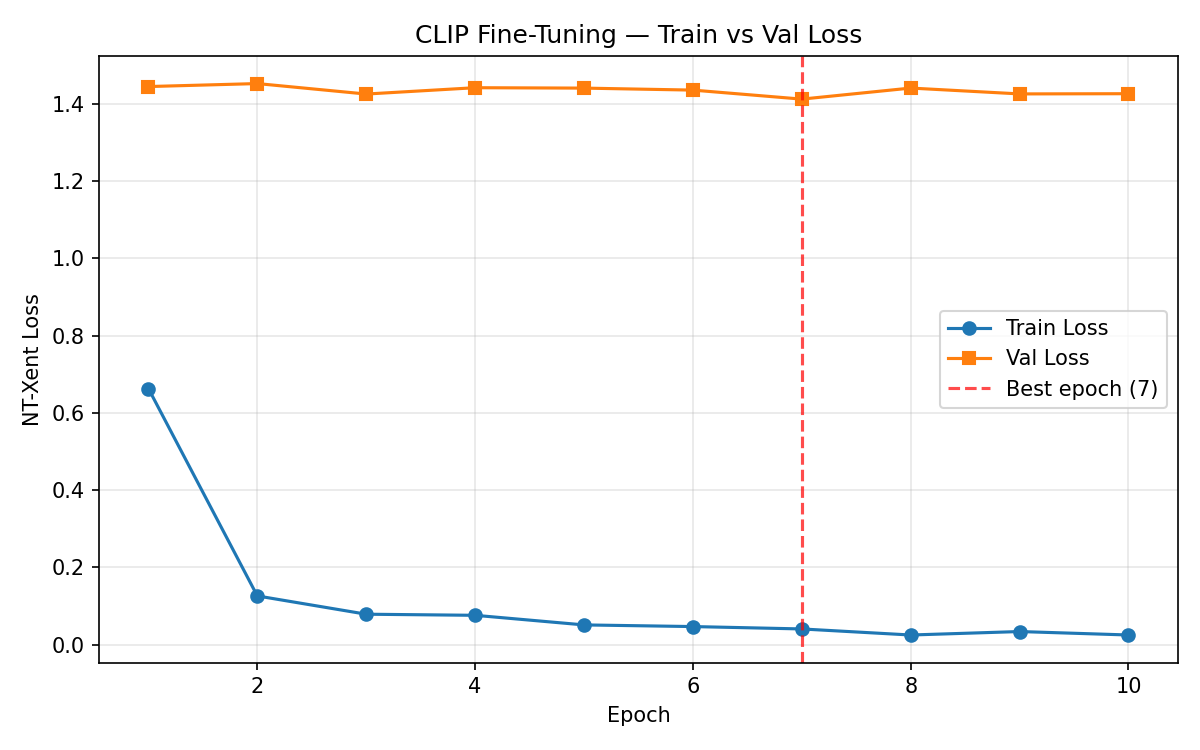

lr_schedule.png


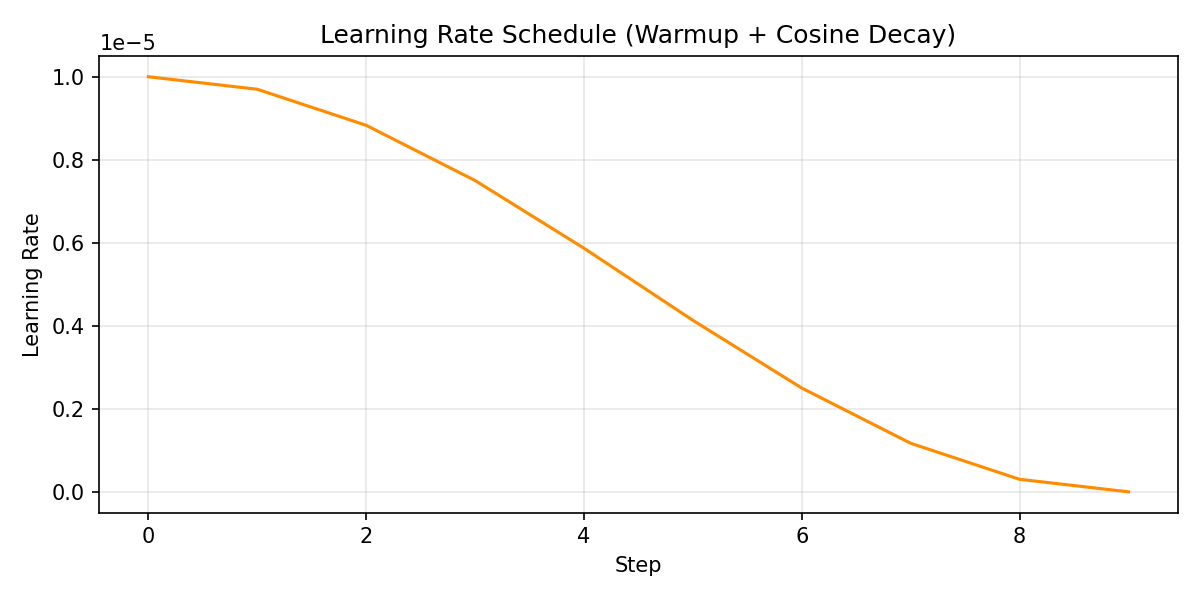

 Epoch  Train Loss  Val Loss
     1      0.6630    1.4447
     2      0.1262    1.4524
     3      0.0788    1.4253
     4      0.0760    1.4417
     5      0.0511    1.4407
     6      0.0468    1.4355
     7      0.0407    1.4122
     8      0.0250    1.4408
     9      0.0340    1.4256
    10      0.0250    1.4262
Best epoch: 7 | Best val loss: 1.4122


In [6]:
# ── Display results ───────────────────────────────────────────────────────────
import json, numpy as np, pandas as pd
from pathlib import Path
from IPython.display import Image as IPImage, display

OUT_DIR = Path("/kaggle/working")

for fname in ["loss_curve.png", "lr_schedule.png"]:
    if (OUT_DIR / fname).exists():
        print(fname)
        display(IPImage(str(OUT_DIR / fname)))

if (OUT_DIR / "training_metrics.json").exists():
    metrics = json.load(open(OUT_DIR / "training_metrics.json"))
    df = pd.DataFrame({
        "Epoch"      : range(1, len(metrics["train_loss"]) + 1),
        "Train Loss" : [round(x, 4) for x in metrics["train_loss"]],
        "Val Loss"   : [round(x, 4) for x in metrics["val_loss"]],
    })
    print(df.to_string(index=False))
    best_ep = int(np.argmin(metrics["val_loss"])) + 1
    print("Best epoch:", best_ep, "| Best val loss:", round(min(metrics["val_loss"]), 4))

In [7]:
# ── Verify checkpoint ─────────────────────────────────────────────────────────
import torch
ckpt = torch.load("/kaggle/working/clip_best.pt", map_location="cpu")
print("Keys      :", list(ckpt.keys()))
print("Best epoch:", ckpt["epoch"])
print("Val loss  :", round(ckpt["val_loss"], 4))
print("Config    :", ckpt["config"])

Keys      : ['epoch', 'model_state', 'val_loss', 'config']
Best epoch: 7
Val loss  : 1.4122
Config    : {'clip_model': 'ViT-L-14', 'clip_pretrain': 'openai', 'finetune_scope': 'full', 'temperature': 0.07, 'alpha': 0.7}
